In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Water_supplied_by_business_entitiess";',
    engine
)
df

,Id,Year,Total,Ground_water,Springs,Water_courses,Reservoirs,Lakes
0,1,2009,4500119.0,114139.0,260618.0,1572063.0,2175430.0,377869.0
1,2,2010,6368589.0,130168.0,532162.0,494360.0,4680863.0,531036.0
2,3,2011,5869979.0,55265.0,480396.0,5061935.0,52171.0,220212.0
3,4,2012,5006246.0,65293.0,147494.0,2639871.0,1901038.0,252549.0
4,5,2013,2537780.0,25504.0,539968.0,959418.0,1012888.0,2.0
5,6,2014,3427825.0,17605.0,1654162.0,481822.0,1010409.0,263827.0
6,7,2015,4282042.0,3920.0,2178473.0,1278812.0,812725.0,8112.0
7,8,2016,3708941.0,21598.0,2665117.0,993315.0,20413.0,0.0
8,9,2017,1290466.0,24494.0,0.0,9715.0,227312.0,1028945.0
9,10,2018,2223388.0,8908.0,0.0,946338.0,925379.0,342763.0


In [3]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028, 2029]})

In [4]:
import os

model_dir = "../models/Water_supplied_by_business_entitiess"
os.makedirs(model_dir, exist_ok=True)

In [5]:
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

forecasts = {}
best_params = {}

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    pipeline = Pipeline([
        ("poly", PolynomialFeatures(include_bias=False)),
        ("ridge", Ridge())
    ])

    param_grid = {
        "poly__degree": [2, 3, 4],
        "ridge__alpha": np.logspace(-3, 3, 10)
    }

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=min(len(X), 5),
        scoring="neg_mean_squared_error"
    )

    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_params[col] = grid.best_params_

    preds = best_model.predict(future_years[["Year"]].values)
    forecasts[col] = preds

    joblib.dump(
        best_model,
        f"{model_dir}/{col}_poly_ridge.pkl"
    )


/Users/miloshkirovski/PycharmProjects/environmental_analytics_project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.67676e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/miloshkirovski/PycharmProjects/environmental_analytics_project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.13287e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/miloshkirovski/PycharmProjects/environmental_analytics_project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.99172e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/miloshkirovski/PycharmProjects/environmental_analytics_project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29265e-20): result may not be accurate.

In [6]:
forecast_df = pd.DataFrame(forecasts, index=future_years["Year"])
forecast_df

,Total,Ground_water,Springs,Water_courses,Reservoirs,Lakes
Year,,,,,,
2025,4.290916e+06,55562.604977,-193977.264812,8.648019e+05,3.081390e+06,80724.709683
2026,5.584622e+06,73003.635896,-335116.340939,1.037180e+06,3.782440e+06,63047.803779
2027,7.201499e+06,92979.739261,-485609.446617,1.253559e+06,4.566656e+06,45362.169252
2028,9.168607e+06,115493.408261,-645456.581844,1.516032e+06,5.434201e+06,27667.806099
2029,1.151304e+07,140547.136082,-814657.746632,1.826695e+06,6.385238e+06,9964.714322


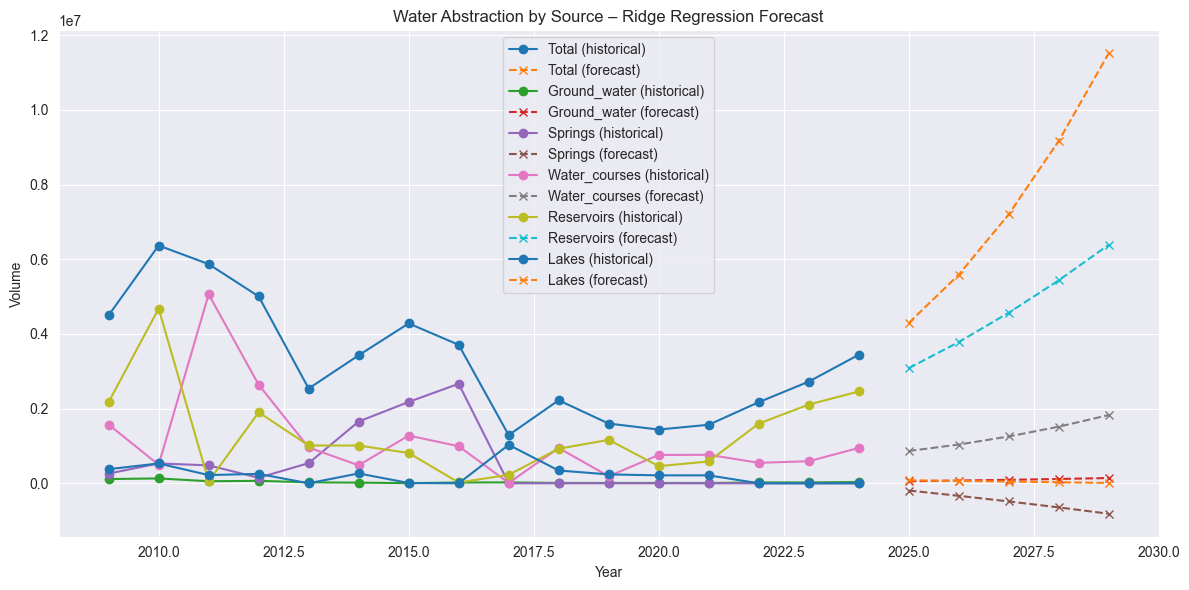

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker="o", label=f"{col} (historical)")
    plt.plot(
        future_years["Year"],
        forecast_df[col],
        marker="x",
        linestyle="--",
        label=f"{col} (forecast)"
    )

plt.title("Water Abstraction by Source – Ridge Regression Forecast")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
